# Car example

from lecture!

In [1]:
# Packages etc
import numpy as np                              # General math
import matplotlib.pyplot as plt                 # For plotting

In [2]:
# Tableau 10 color scheme (hex)
tabBlue   = "#4E79A7"
tabGreen  = "#59A14F"
tabBrown  = "#9C755F"
tabOrange = "#F28E2B"
tabYellow = "#EDC948"
tabGray   = "#BAB0AC"
tabRed    = "#E15759"
tabPurple = "#B07AA1"
tabTeal   = "#76B7B2"
tabPink   = "#FF9DA7"

## Physics

In [3]:
# Car parameters
k = 7e3       # Engine acceleration coefficient (N)
m = 1200    # car mass  (kg)
c = 500    # Friction factor air
T_dead = 0.6
F_dist = -200    # Distortion, may be from engine itself

In [4]:
# "Make a step", so getting the new state from the old state after one dt timestep considering the actions
def step(state, action, dt):
    # Read state and action
    x, x_dot = state              # position, velocity (current state)
    u = action                      # Throttle pedal position (in %)

    # Definition of the differential equation
    x_ddot = (k * np.tanh(u) - c * x_dot - F_dist) / m    # Acceleration nonlinear ODE

    # Explicit Euler update
    x_new         = x         + dt * x_dot
    x_dot_new     = x_dot     + dt * x_ddot

    return np.array([x_new, x_dot_new])

## Simulation

In [5]:
# Simulation parameters
dt = 1e-3           # Step size (smaller is numerically more stable, but needs more time to calculate)
time_total = 20      # Total time
steps = int(time_total / dt)    # Number of simulation steps

# For plotting we need to save the states over time
time = np.linspace(0, time_total, steps)

def simulation(initial_state, actor_function):
    # log only x, v
    states_log = np.zeros((steps, 2))
    action_log = np.zeros(steps)

    # internal state includes u_eff
    state = np.array(initial_state, dtype=float)  # [x, v, u_eff]

    # initial log
    states_log[0, :] = state[:2]

    # Motor has dead time
    d = int(T_dead / dt)           # Totzeit in Schritten
    buf = np.zeros(d)              # startet mit 0

    for i in range(steps - 1):
        t = i * dt

        u = 0.0 if actor_function is None else actor_function(state, t)
        action_log[i] = u

        u_in = u if d == 0 else buf[0]   # verzögertes u
        if d:
            buf[:-1] = buf[1:]
            buf[-1]  = u

        state = step(state, u_in, dt)        # step bekommt u_in
        states_log[i + 1, :] = state[:2] # log only x, v

    action_log[-1] = action_log[-2]
    return states_log, action_log


## Plots

In [6]:
# Plot of the state over time
def show_plots(x_dot, u, x_dot_set = None, title = None):
    plt.close('all')
    fig, axs = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    
    labels = [r'Velocity $v\,[\mathrm{m/s}]$', r'Throttle $u\,[-]$']
    colors = [tabBlue, tabGreen, tabRed]

    if x_dot_set is not None:
        axs[0].axhline(y = x_dot_set, color=tabOrange,linestyle='--', label=r"$r(t)$", linewidth=4)

    axs[0].plot(time, x_dot[:, 1], colors[0], label=r"$v(t)$", linewidth=4)
    axs[0].set_ylabel(labels[0])
    axs[0].set_ylim(min(np.min(x_dot[:, 1]), max(np.max(x_dot[:, 1]), x_dot_set) * 1.01))
    axs[0].legend(loc="lower right")
    axs[0].grid()

    axs[1].plot(time, u[:], colors[2], linewidth=4)
    axs[1].set_ylabel(labels[1])
    axs[1].set_ylim(0, 1.01)
    axs[1].grid()
        
    axs[-1].set_xlim(0, time[-1])
    axs[-1].set_xlabel(r'Time $t$ [s]')
    if title is None:
        fig.suptitle("States and actions over time", fontsize=14)    
    else:
        fig.suptitle(title, fontsize=14)    
    plt.tight_layout()

    if title:
        plt.savefig(title + ".pdf")
    plt.show()

## PID

In [7]:
def make_af_pid(x_dot_set, Kp, Ki, Kd, u_max=1.0):
    integral = 0.0
    last_error = 0.0

    def pid_actor(state, t):
        nonlocal integral, last_error

        # Get state (
        # keep in mind: we just measure theta in reality, since this is the sensor output y(t) --> We have to work only with theta
        x_dot = state[1]
        error = x_dot_set - x_dot

        integral += error * dt
        integral = np.clip(integral, -5.0, 5.0)  # anti-windup: Prevents extreme integral values for long integration times

        derivative = (error - last_error) / dt
        last_error = error

        u = Kp * error + Ki * integral + Kd * derivative     # Actor needs to work against the error!

        return np.clip(u, 0, u_max)

    return pid_actor

In [8]:
# Get initial state (standing vehicle)
init_state = np.array([
    0,                           # x
    0                           # x_dot
])

# Set the desired velocity!
x_dot_set = 5   # Set wanted velocity (m/s)

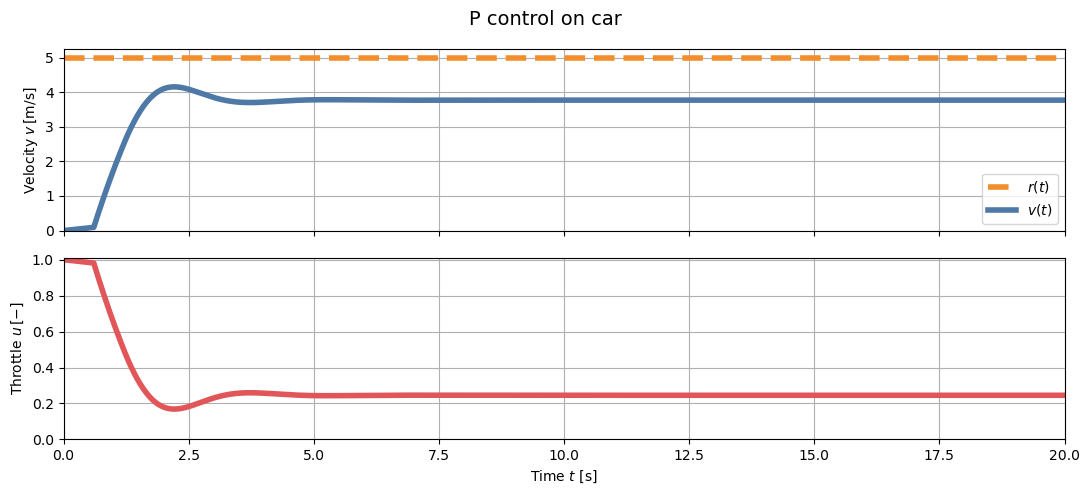

In [9]:
# Simple P tuner

v_P, u_P = simulation(init_state, actor_function=make_af_pid(x_dot_set=x_dot_set, Kp=0.2, Ki=0, Kd=0))
show_plots(v_P, u_P, x_dot_set=x_dot_set, title="P control on car")

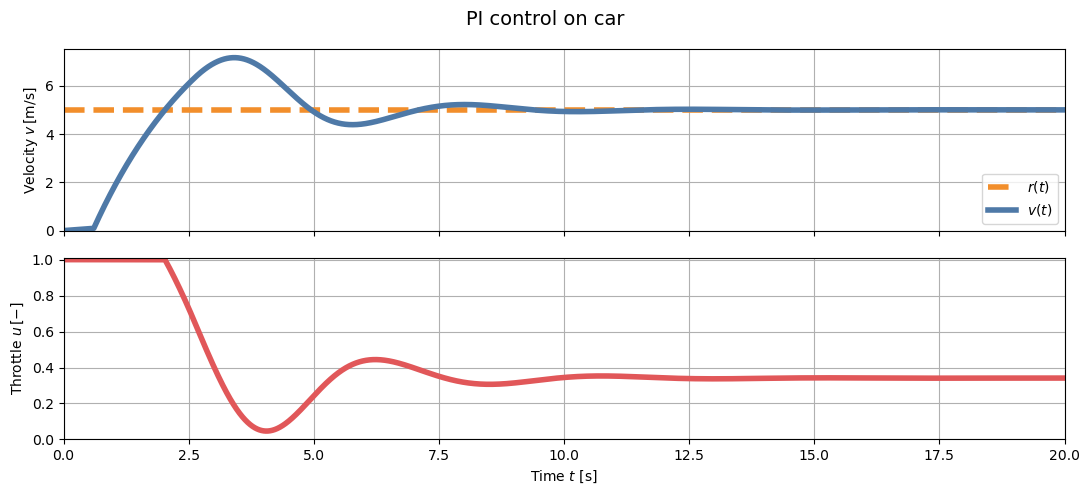

In [10]:
# PI tuner

v_PI, u_PI = simulation(init_state, actor_function=make_af_pid(x_dot_set=x_dot_set, Kp=0.2, Ki=0.2, Kd=0))
show_plots(v_PI, u_PI, x_dot_set=x_dot_set, title="PI control on car")

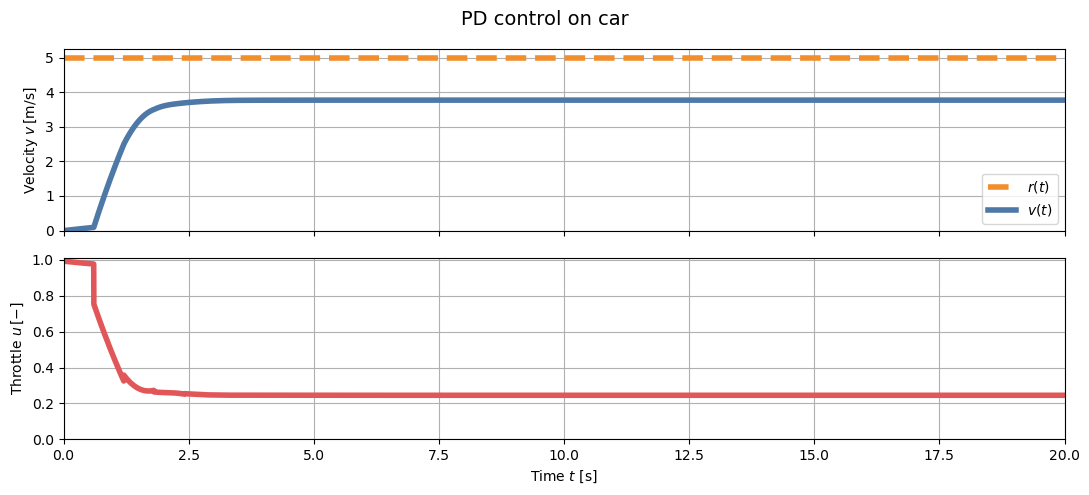

In [11]:
# PD tuner

v_PD, u_PD = simulation(init_state, actor_function=make_af_pid(x_dot_set=x_dot_set, Kp=0.2, Ki=0, Kd=0.05))
show_plots(v_PD, u_PD, x_dot_set=x_dot_set, title="PD control on car")

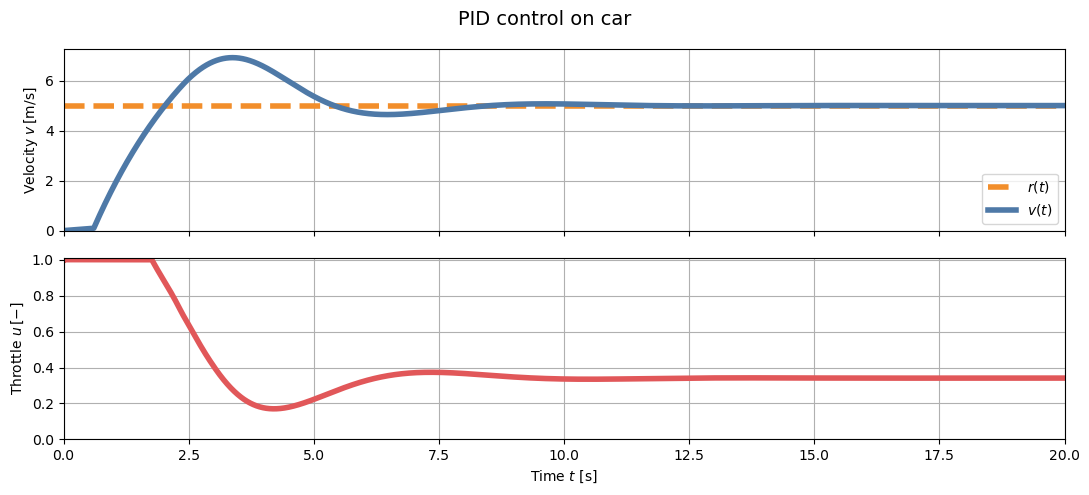

In [12]:
# PID tuner

v_PID, u_PID = simulation(init_state, actor_function=make_af_pid(x_dot_set=x_dot_set, Kp=0.2, Ki=0.2, Kd=0.05))
show_plots(v_PID, u_PID, x_dot_set=x_dot_set, title="PID control on car")

# Ziegler-Nichols method

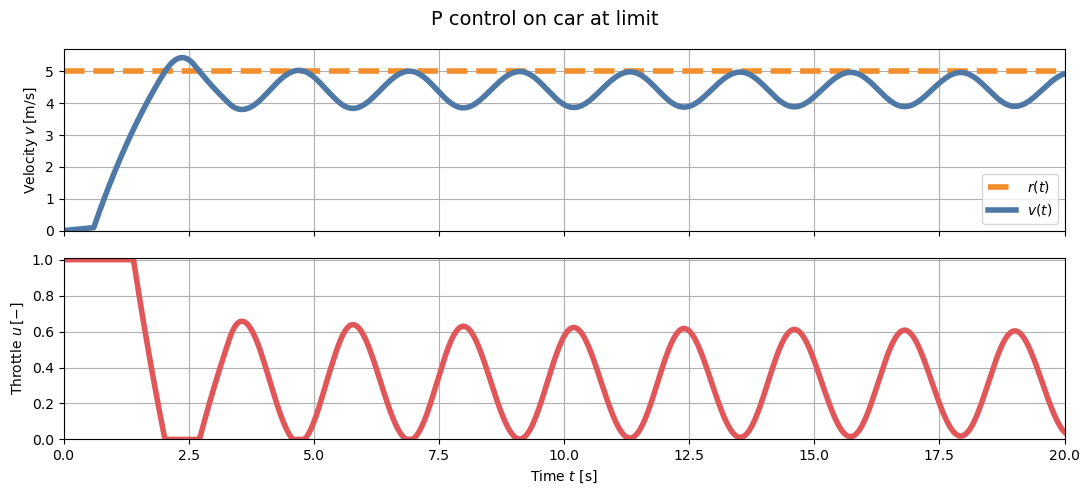

In [13]:
# Simple P tuner
Ku = 0.55   # Change till steady oscillations
v_ZN, u_ZN = simulation(init_state, actor_function=make_af_pid(x_dot_set=x_dot_set, Kp=Ku, Ki=0, Kd=0))
show_plots(v_ZN, u_ZN, x_dot_set=x_dot_set, title="P control on car at limit")

In [14]:
# Ziegler-Nichols
Tu = 2.2    # Read "by eye"

# Get from table
Kp_ZN = 0.6*Ku
Ki_ZN = 1.2*Ku/Tu
Kd_ZN = 0.075*Ku*Tu

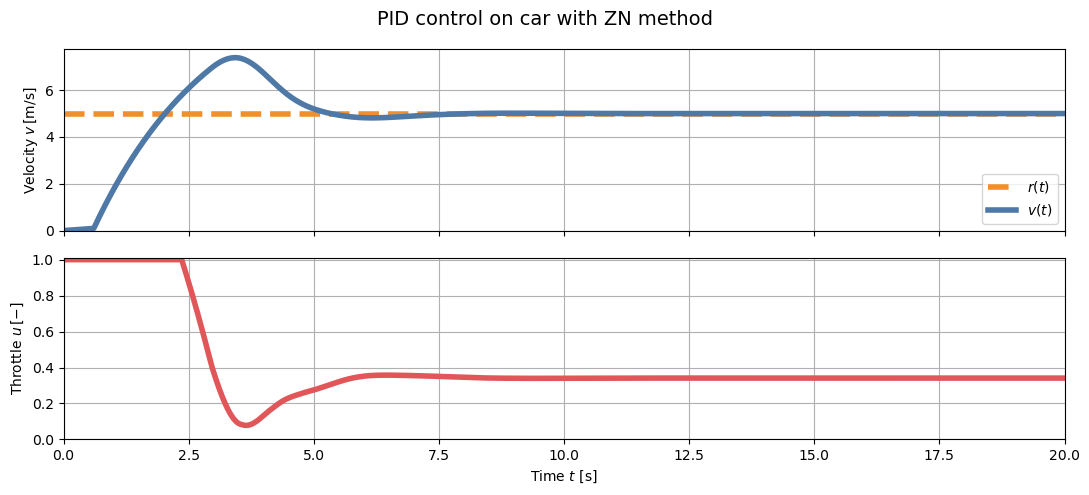

In [15]:
# ZN tuned PID

v_ZN, u_ZN = simulation(init_state, actor_function=make_af_pid(x_dot_set=x_dot_set, Kp=Kp_ZN, Ki=Ki_ZN, Kd=Kd_ZN))
show_plots(v_ZN, u_ZN, x_dot_set=x_dot_set, title="PID control on car with ZN method")

# LQR

Version 1: Linearization in $..$ (0)

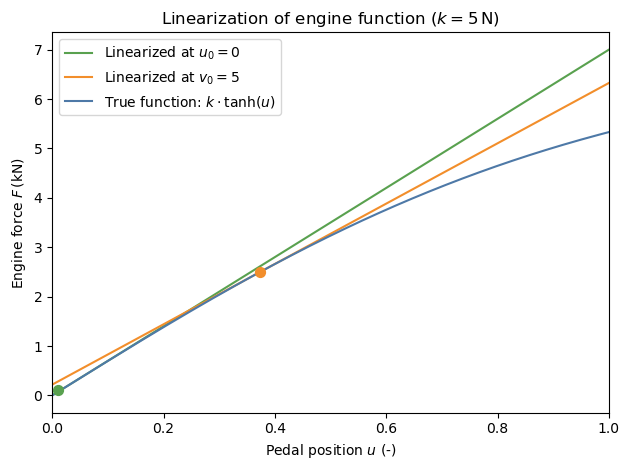

In [16]:
# Linearization of engine function
u = np.linspace(0, 1, 400)
u0 = np.arctanh(5*c/k)

plt.plot(u, k * u * 1e-3, tabGreen, label=r"Linearized at $u_0=0$")
plt.plot(u, (5*c+(k - 25*c**2/k)*(u-u0)) * 1e-3, tabOrange, label=r"Linearized at $v_0=5$")
plt.plot(u, k * np.tanh(u) * 1e-3, tabBlue, label=r"True function: $k \cdot \tanh(u)$")
plt.scatter(0.01, 0.1, marker='o', s=50, color=tabGreen, zorder=10)
plt.scatter(u0, 5*c *1e-3, marker='o', s=50, color=tabOrange, zorder=10)
plt.xlabel(r"Pedal position $u$ (-)")
plt.ylabel(r"Engine force $F\,(\mathrm{kN})$")
plt.title(r"Linearization of engine function ($k=5\,\mathrm{N}$)")
plt.xlim(0,1)
#plt.ylim(0,k*1e-3)
plt.legend()
plt.tight_layout()
plt.savefig("engine_function.pdf")
plt.show()
plt.close()

In [17]:
# State space representation (in u_0 = 0 and x_0 = [0, 0])
A = np.array([[0.0, 1.0],[0.0, -c/m]], dtype=float)

B = np.array([[0.0],[k/m]], dtype=float)

C = np.array([[0.0, 1.0]], dtype=float)

D = np.array([[0.0]], dtype=float)

In [18]:
# Stability
print(np.linalg.eigvals(A))

[ 0.         -0.41666667]


In [19]:
# Controllability
CON = np.hstack([B, A @ B])

# Rank test
rank_CON = np.linalg.matrix_rank(CON)
print("CON=\n", CON)
print("rank(CON)=", rank_CON)

CON=
 [[ 0.          5.83333333]
 [ 5.83333333 -2.43055556]]
rank(CON)= 2


In [20]:
# Observability matrix
OBS = np.vstack([C, C @ A])

# Rank test
rank_OBS = np.linalg.matrix_rank(OBS)
print("OBS=\n", OBS)
print("rank(OBS)=", rank_OBS)

OBS=
 [[ 0.          1.        ]
 [ 0.         -0.41666667]]
rank(OBS)= 1


In [21]:
# Coordinate transformation to v_0 = 5

beta = 1-(5*c/k)**2

# State space representation
A = np.array([[0, 1],[0, -c/m]])

B_new = B * beta

C = np.array([[0, 1]])

D = np.array([[0]])

In [22]:
# Calculate Gain vector K
from scipy.linalg import solve_continuous_are

Q = np.diag([0.0, 4])   # nur x_dot bestrafen
R = np.array([[25]])

P = solve_continuous_are(A, B_new, Q, R)
K = np.linalg.solve(R, B.T @ P)   # = R^{-1} B^T P, shape (1,2)

print(K)
# Check analytical result from slides
print(4.42*c/k)

[[-1.86045681e-18  3.74143759e-01]]
0.3157142857142857


In [23]:
# Stability of closed circuit
A_cl = A - B_new @ K
print(np.linalg.eigvals(A_cl))

[-4.44089210e-16 -2.32079115e+00]


In [24]:
def make_af_lqr(u_set, v_set, K, u_max=1.0):
    K = np.asarray(K, dtype=float)

    def lqr_actor(state, t):
        x = np.asarray(state, dtype=float)
        v_tilde = x[1] - v_set

        x_tilde = np.array([0.0, v_tilde], dtype=float)

        du = -float(np.squeeze(K @ x_tilde))
        u = u_set + du          # Coordinate back-transformation to get absolute values
        return np.clip(u, 0, u_max)

    return lqr_actor

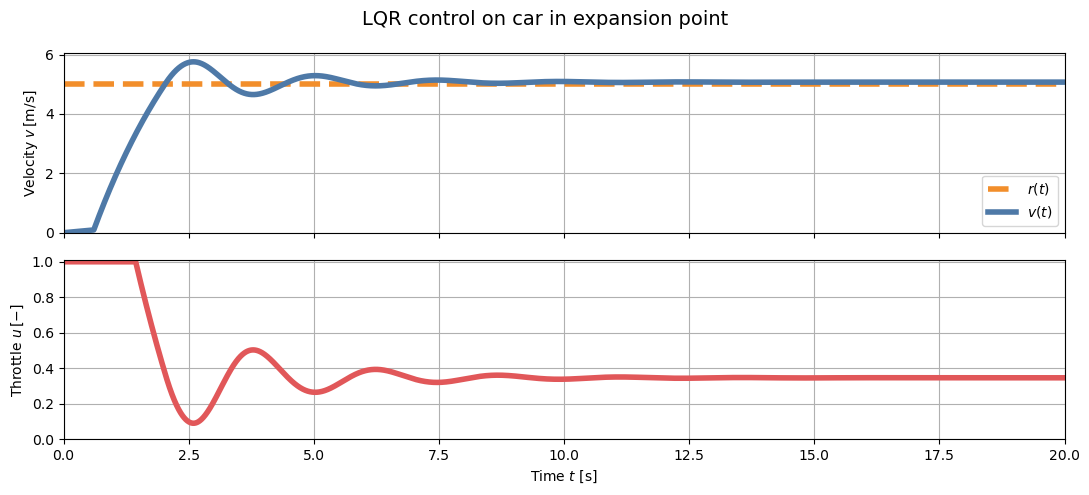

In [26]:
# LQR tuner in expansion point
v_set = 5
u_set = np.arctanh(5*c/k)

# Set init state as 90 % to see speedup
init_state_LQR = np.array([
    0,                           # x
    0,                           # x_dot
])

v_LQR2, u_LQR2 = simulation(init_state_LQR, actor_function=make_af_lqr(v_set=v_set, u_set=u_set, K=K))
show_plots(v_LQR2, u_LQR2, x_dot_set=v_set, title="LQR control on car in expansion point")

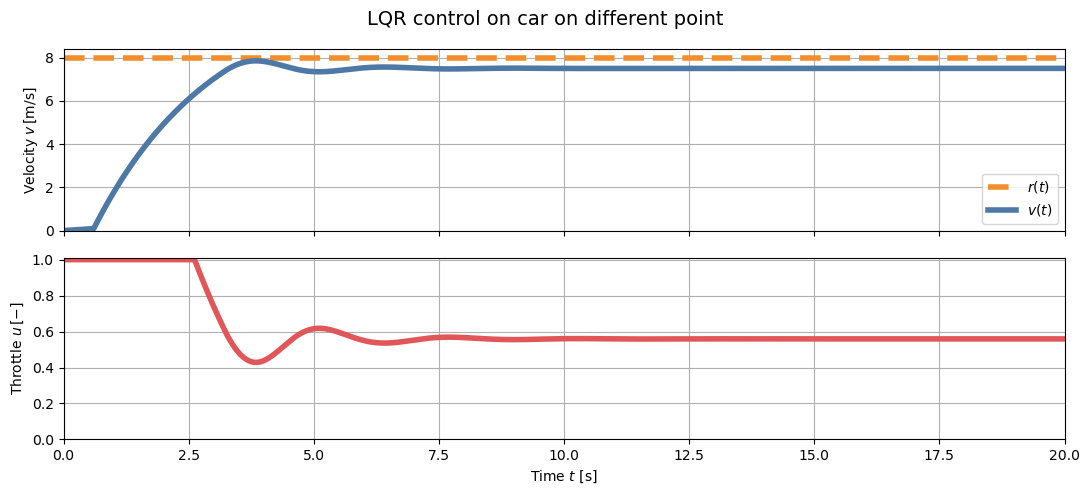

In [27]:
# LQR tuner out of expansion point
v_set = 8

# Set init state as 90 % to see speedup
init_state_LQR = np.array([
    0.0,                           # x
    0,                           # x_dot
])

v_LQR2, u_LQR2 = simulation(init_state_LQR, actor_function=make_af_lqr(v_set=v_set, u_set=u_set, K=K))
show_plots(v_LQR2, u_LQR2, x_dot_set=v_set, title="LQR control on car on different point")

# LQI

In [28]:
# LQI expansion
A_new = np.array([[0, 1, 0],[0, -c/m, 0], [0, -1, 0]], dtype=float)

B_new = np.array([[0],[k/m*beta], [0]], dtype=float)


Q_new = np.diag([0, 4, 0.5])
R_new = np.array([[16]])

P_new = solve_continuous_are(A_new, B_new, Q_new, R_new)
K_new = np.linalg.solve(R_new, B_new.T @ P_new)   # = R^{-1} B^T P, shape (1,2)

print(K_new)

[[-2.87676831e-18  4.89244280e-01 -1.76776695e-01]]


In [29]:
def make_af_lqi(u_set, v_set, K, u_max=1.0):
    K = np.asarray(K, dtype=float)
    z = 0.0

    def lqi_actor(state, t):
        nonlocal z
        # We need tilde (transformed) values in here
        x = np.asarray(state, dtype=float)
        v_tilde = x[1] - v_set
        z -= v_tilde * dt
        z = np.clip(z, -1, 1)

        x_tilde = np.array([0.0, v_tilde, z], dtype=float)

        du = -float(np.squeeze(K @ x_tilde))
        u = u_set + du          # Coordinate back-transformation to get absolute values
        return np.clip(u, 0, u_max)


    return lqi_actor


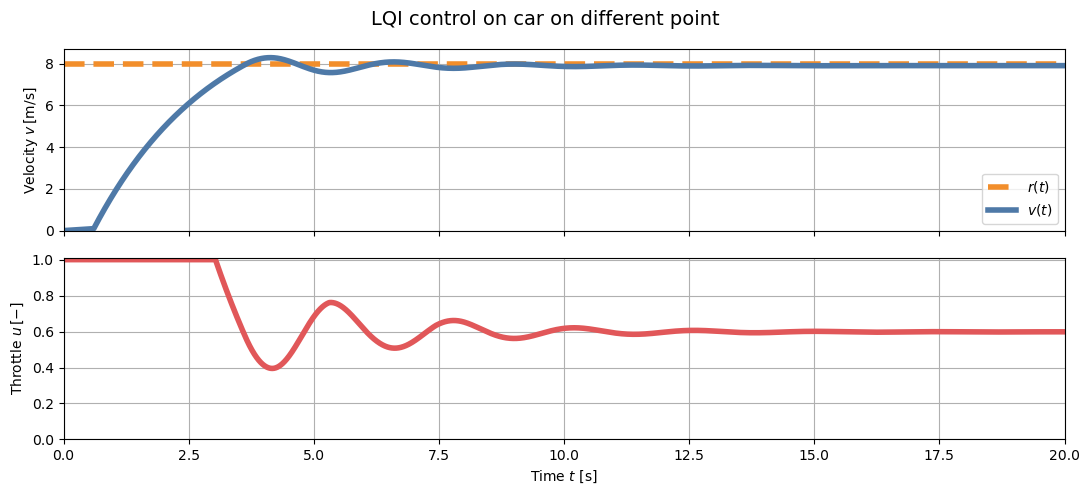

In [30]:
# LQR tuner out of expansion point
v_set = 8
u_set = np.arctanh(5*c/k)

v_LQI, u_LQI = simulation(init_state_LQR, actor_function=make_af_lqi(v_set=v_set, u_set=u_set, K=K_new))
show_plots(v_LQI, u_LQI, x_dot_set=v_set, title="LQI control on car on different point")